In [116]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from labellines import *

In [117]:
datasets_ordered = [
	'scrna-embryo',
	'scrna-neuro',
	'lit-adrd',
	'lit-pd1',
	'meta-gut',
]

In [118]:
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

def make_fading_cmap(cmap_name='viridis', start_alpha=0.0, end_alpha=1.0, N=256):
    """
    Creates a new colormap that fades from a starting alpha to an ending alpha.
    """
    # Get the existing colormap
    cmap = cm.get_cmap(cmap_name)
    # Get all the colors from the colormap
    colors = cmap(np.arange(N))
    
    # Create a linearly increasing alpha channel
    alphas = np.linspace(start_alpha, end_alpha, N)
    
    # Apply the new alpha channel to the colors array (the 4th column, index 3)
    colors[:, :3] = [.5, .5, .5]  # Set RGB to a constant color (e.g., gray)
    colors[:, 3] = alphas
    
    # Create a new ListedColormap
    fading_cmap = ListedColormap(colors, name=f'{cmap_name}_fading')
    
    return fading_cmap



In [119]:
def harmonic_mean(x, y):
    return 2 * x * y / (x + y)

In [120]:
data2name = {
	'scrna-embryo': 'scRNA-seq (Embryo)',
	'scrna-neuro': 'scRNA-seq (Neuro)',
	#'scrna-lpm': 'scRNA-seq (Embryo)',
	'meta-gut': 'Metagenomes',
	'lit-adrd': 'Literature (ADRD)',
	'lit-pd1': 'Literature (PD-1)',
}

data2order = {
	'scrna-embryo': 0,
	'scrna-neuro': 1,
	'lit-adrd': 2,
	'lit-pd1': 3,
	'meta-gut': 4,
}

df = pd.read_csv('../data/metrics/metrics.main.csv')
df['layout'] = df['layout'].str.upper()
sns.set_style("ticks")
sns.set_context("notebook", rc={"lines.linewidth": 3})

# Group means and stds
grouped = df.groupby(['dataset', 'layout'])

means = grouped[['KNN', 'SVR']].mean().reset_index()
stds = grouped[['KNN', 'SVR']].std().reset_index()

# Merge mean + std
stats = means.merge(stds, on=['dataset', 'layout'], suffixes=('_mean', '_std'))

datasets = datasets_ordered  #list(stats['dataset'].unique())
datasets.sort(key=lambda x: stats[stats['dataset'] == x][stats[stats['dataset'] == x]['layout'] == 'UMAP-MD0.5']['KNN_mean'].values[0])

# ── Styling ──
palette = sns.color_palette("Set2", n_colors=len(datasets)+1)
color_map = {ds: palette[int(i)] for i, ds in enumerate(datasets)}

ds2color = {
    'scrna-embryo': palette[1],
    # 'scrna-embryo' : palette[0],
    'scrna-neuro': palette[4],
    'lit-pd1': palette[2],
    'lit-adrd': palette[0],
    'meta-gut': palette[3],
}

# Define layout to marker mapping (shape+label)
layout_markers = {
    'UMAP-MD0.5': 'D',
    'UMAP-MD0.1': 's',
    'IRIS-B0.95': 'o',
}


def plot(layouts):
    handles_labels = []  # list of tuples (layout_order, handle, label)
    
    fig, ax = plt.subplots(figsize=(6,6))

    # Create grid
    x = np.linspace(0, 1, 400)
    y = np.linspace(0, 1, 400)
    X, Y = np.meshgrid(x, y)

    # Harmonic mean - TRANSPOSED: swap X and Y in the computation for plotting
    H = 2 * X * Y / (X + Y)

    # Plot contours (isolines) - but swap X/Y so that contours orient with axes transposed
    manual_locations = [(x/(2*0.95-x), 0.95) for x in np.linspace(0, 0.875, 10)]  # Place labels along the 'now-horizontal' diagonal

    contours = plt.contour(Y, X, H, levels=10, cmap=make_fading_cmap(cmap_name='Grays', start_alpha=0.25, end_alpha=1.0), linewidths=1, linestyles='--')
    plt.clabel(contours, inline=True, fontsize=12, colors='gray', manual=manual_locations)
    plt.grid(False)

    for layout in layouts.keys():
        sub = stats[stats['layout'] == layout]

        for dataset in datasets:
            curr = sub[sub['dataset'] == dataset]
            if curr.empty:
                continue
            # Swap axes: now x gets former y, and y gets former x
            orig_y, orig_x = curr[['KNN_mean', 'SVR_mean']].values[0]
            sy, sx = curr[['KNN_std', 'SVR_std']].values[0]
            x = orig_y
            y = orig_x
            sx2 = sy
            sy2 = sx

            h = ax.scatter(
                x, y, 
                marker=layout_markers[layout], 
                s=80 if layout == 'UMAP-MD0.5' else 110, 
                facecolors='none',
                edgecolors=ds2color[dataset],
                linewidths=1.5,
                #label=f"{dataset} - {layout_markers[layout]['label']}"
            )
            handles_labels.append((list(layouts.keys()).index(layout)*len(datasets)+data2order[dataset], h, f"   {data2name[dataset]}" if layout == 'IRIS-B0.95' else None) )
            # Ellipse: width in x spans sx2, height in y spans sy2
            e = Ellipse((x, y), width=2*sx2, height=2*sy2, alpha=0.4, color=ds2color[dataset], linewidth=1)
            ax.add_patch(e)

    # Sort the handles/labels by layout order
    handles_labels.sort(key=lambda z: z[0])

    # Unpack
    handles = [h for _, h, _ in handles_labels]
    labels = [l for _, _, l in handles_labels]

    # Position the legend on the left side and about a third of the way down
    legend = ax.legend(
        handles, labels, 
        bbox_to_anchor=(0., 0.4),  # x: just left of the axes; y: ~1/3 down from the top
        loc='center left',
        frameon=True,
        ncol=len(layout_order),
        alignment='left',
        title=f" {layouts[list(layouts.keys())[0]]}   {layouts[list(layouts.keys())[1]]}",
        borderaxespad=1.0,    # Increase padding between legend and axes
        handletextpad=0,    # Increase space between handle and label
        columnspacing=2,    # Increase space between columns
        labelspacing=.5      # Increase vertical space between labels
    )
    legend.get_frame().set_alpha(0.75)  # decrease legend background alpha (0.5 is semi-transparent)
    if legend.get_title() is not None:
        legend.get_title().set_ha('left')

    # Swap axis labels to reflect transpose
    ax.set_xlabel("Class structuring (KNN)")
    ax.set_ylabel("Time structuring (SVR)")
    #ax.set_title("UMAP → IRIS → UMAP-S")
    ax.set_xlim(-0.1, 1)
    ax.set_ylim(-0.1, 1)

    plt.tight_layout()
    plt.savefig('fig-results.pdf')


/var/folders/s0/mbq48jy95g72fzz_f2qgh95942jfwj/T/ipykernel_12548/3189198549.py:67: RuntimeWarning: invalid value encountered in divide
  H = 2 * X * Y / (X + Y)
/var/folders/s0/mbq48jy95g72fzz_f2qgh95942jfwj/T/ipykernel_12548/3312525147.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


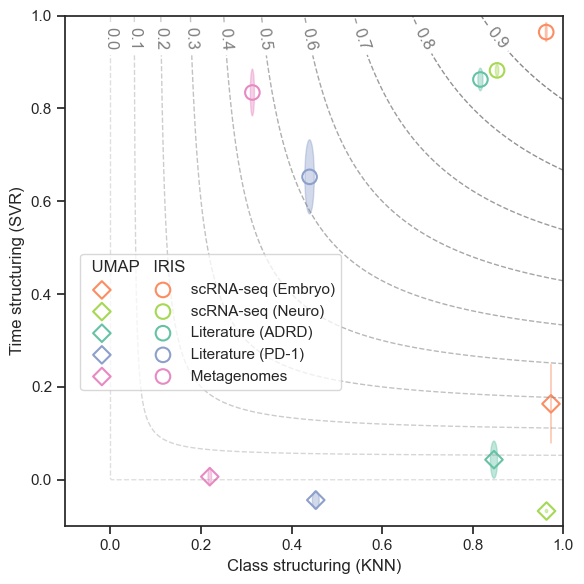

In [121]:
plot({'UMAP-MD0.5': 'UMAP', 'IRIS-B0.95': 'IRIS'})

/var/folders/s0/mbq48jy95g72fzz_f2qgh95942jfwj/T/ipykernel_12548/3189198549.py:67: RuntimeWarning: invalid value encountered in divide
  H = 2 * X * Y / (X + Y)
/var/folders/s0/mbq48jy95g72fzz_f2qgh95942jfwj/T/ipykernel_12548/3312525147.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


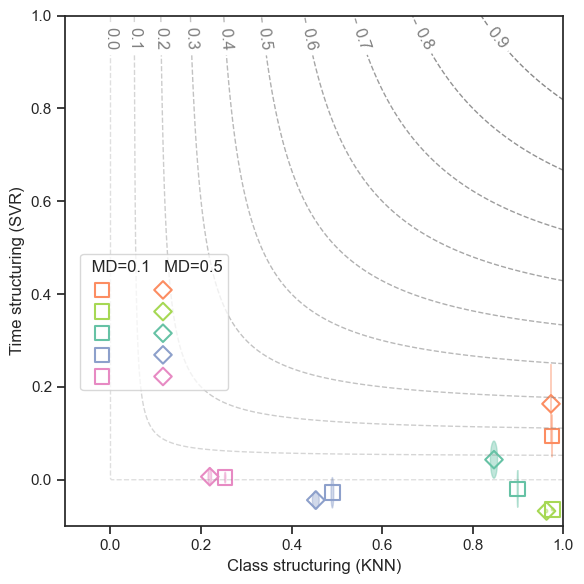

In [122]:
plot({'UMAP-MD0.1':'MD=0.1', 'UMAP-MD0.5':'MD=0.5'})

In [123]:
# for optimizing rho
#
from scipy.special import rel_entr
zeta = 0.1
bins = 100
p=np.array([(2.*zeta/bins + (((x+1.)/bins)**2-(x/bins)**2)*(1-zeta))/(1.+zeta) for x in range(bins)])
tests = np.arange(-5, 5, 0.01)

datasets = ['scrna-embryo', 'lit-pd1', 'lit-adrd', 'scrna-neuro', 'meta-gut']
layouts = ['iris-b.95', 'umap-md0.5']

def cost(time, zeta, rho):
	q = np.histogram(zeta+(1-zeta)*np.power(time, np.exp(rho)), bins=100, density=True)[0]+1
	return np.sum(rel_entr(p, q/np.sum(q)))

def get_rho(t):
	return tests[np.argmin([cost(t, 0.1, x) for x in tests])]


In [124]:
data = {}
times = {}
times_r = {}
for dataset in datasets_ordered:
	for layout in layouts:
		t = np.load(f'../data/inputs/{dataset}.time.npy').astype(dtype=np.float32)
		times[dataset] = t
		t = (t-t.min())/(t.max()-t.min())
		c = [cost(t, 0.1, x) for x in tests]
		data[dataset] = c
		rho = get_rho(t)
		t_r = np.power(t, np.exp(rho))
		times_r[dataset] = t_r



/var/folders/s0/mbq48jy95g72fzz_f2qgh95942jfwj/T/ipykernel_12548/1975770984.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
/var/folders/s0/mbq48jy95g72fzz_f2qgh95942jfwj/T/ipykernel_12548/1975770984.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
/var/folders/s0/mbq48jy95g72fzz_f2qgh95942jfwj/T/ipykernel_12548/1975770984.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


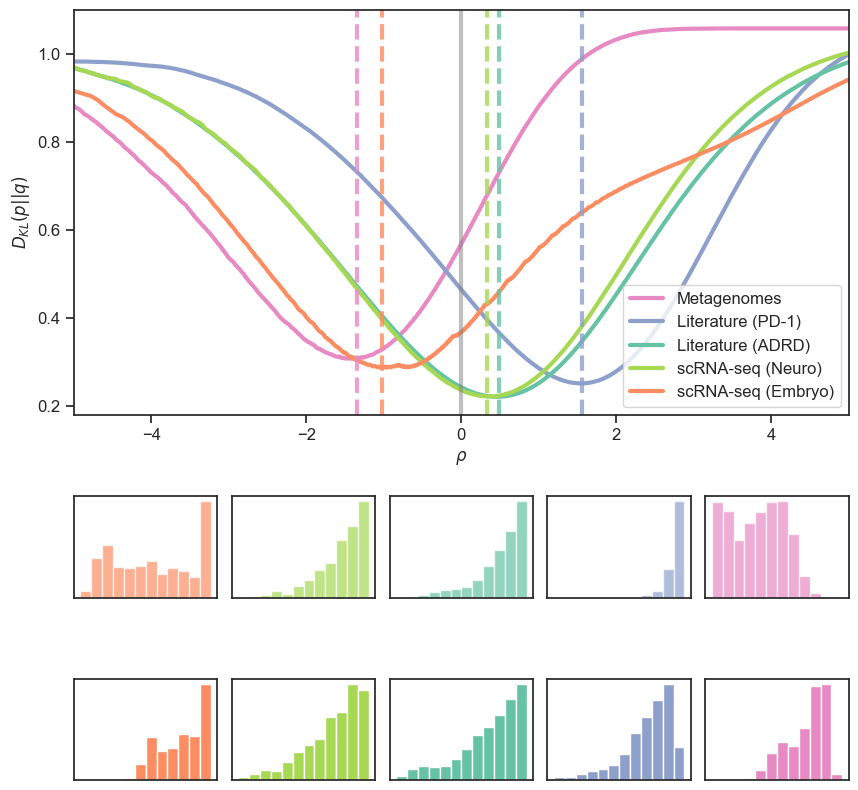

In [125]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("ticks")
sns.set_context("notebook", rc={"lines.linewidth": 3})

df = pd.DataFrame({
    "x": np.tile(tests, len(data)),
    "value": np.concatenate(list(data.values())),
    "dataset": np.repeat(list(data.keys()), len(next(iter(data.values()))))
})

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(3, len(data), height_ratios=[4, 1, 1], hspace=0.4)

ax = fig.add_subplot(gs[0, :])

# label axes
ax.set_xlabel('$\\rho$', fontsize=12)
ax.set_ylabel('$D_{KL}(p||q)$', fontsize=12)
ax.set_xlim(-5, 5)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
sns.lineplot(data=df, x="x", y="value", hue="dataset", palette=ds2color, ax=ax)

for name in datasets_ordered:
    min_idx = tests[np.argmin(data[name])]
    ax.axvline(
        x=min_idx,
        linestyle="--",
        color=ds2color[name],
        alpha=0.8
    )

ax.axvline(x=0, linestyle="-", color='gray', alpha=0.5)

for i, name in enumerate(reversed(datasets_ordered)):
    ax_hist = fig.add_subplot(gs[1, i])
    ax_hist.hist(times[name], bins=12, color=ds2color[name], alpha=0.7)
    ax_hist.set_xticks([])
    ax_hist.set_yticks([])

    ax_hist = fig.add_subplot(gs[2, i])
    ax_hist.hist(times_r[name], bins=12, color=ds2color[name])
    ax_hist.set_xticks([])
    ax_hist.set_yticks([])

fig.subplots_adjust(hspace=0, wspace=0.1) # Set hspace and wspace to a small fraction or 0

from matplotlib.lines import Line2D
handles, _ = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=ds2color[key], lw=3, label=data2name[key])
    for key in data.keys()
]
ax.legend(handles=custom_handles, loc='lower right', fontsize=12, title=None)

plt.tight_layout()
plt.savefig('fig-rho-opt.pdf', bbox_inches='tight')

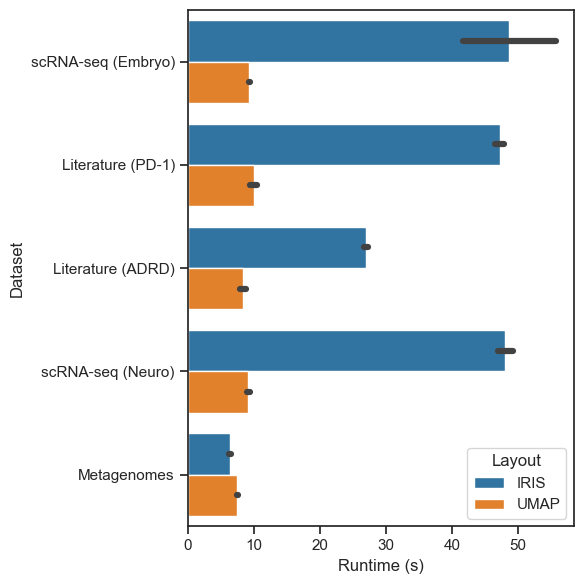

In [126]:
# Grouped horizontal bar chart: runtimes per layout within each dataset (grouped bars)

df = pd.read_csv('../data/metrics/metrics.main.csv')
df = df[df['layout'].isin(['IRIS-B0.95', 'UMAP-MD0.5'])]

df = df.copy()
df['dataset_label'] = df['dataset'].map(data2name)
df['layout_label'] = df['layout'].map({'IRIS-B0.95': 'IRIS', 'UMAP-MD0.5': 'UMAP'})

plt.figure(figsize=(6,6))
sns.barplot(y='dataset_label', x='runtime', hue='layout_label', data=df, errorbar='sd', orient='h')
plt.xlabel('Runtime (s)')
plt.ylabel('Dataset')
#plt.title('Runtimes by Dataset and Layout')
plt.legend(title='Layout')	
plt.tight_layout()
plt.savefig('fig-runtimes.pdf')